<a href="https://colab.research.google.com/github/omkarmohite056-alt/OM-AB-Regression---Yes-Bank-Stock-Closing-Price-Prediction/blob/main/OM_AB_Yes_Bank.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **YesBank Stock Closing Price Prediction**    -



##### **Project Type**    - Regression
##### **Contribution**    - Individual
##### **Team Member 1 - Omkar Nitin Mohite

# **Project Summary -**

This project focuses on analyzing and predicting the monthly closing stock price of Yes Bank, one of India’s prominent private sector banks, using historical stock price data from July 2005 to November 2020. Since 2018, Yes Bank has been under intense public scrutiny due to a major fraud case involving its former leadership, which resulted in a dramatic decline in stock prices. The primary objective of this study was to examine how such market-disruptive events affected stock price behavior and to evaluate whether predictive models can effectively forecast monthly closing prices under volatile conditions.

The dataset consisted of monthly Open, High, Low, and Close prices. Initial exploratory data analysis revealed right-skewed distributions across all price variables, indicating the presence of extreme values. A time-series visualization highlighted a strong upward trend until 2018, followed by a sharp crash and prolonged decline. These extreme values were identified as genuine market events rather than data errors; therefore, no outlier removal was performed to preserve critical business information.

Data preprocessing involved converting the date column into a datetime format and ensuring chronological ordering. Feature engineering played a key role in capturing temporal and market dynamics. The closing price was log-transformed to stabilize variance and reduce skewness. Lagged closing prices were created to capture temporal dependence, while volatility and trend-related features such as high–low range, open–close range, and moving averages were introduced to reflect market uncertainty and short-term trends. Rows containing missing values generated from lag and rolling operations were removed in a controlled manner.

Feature selection was performed to eliminate redundancy, prevent multicollinearity, and avoid data leakage. Raw price columns, time identifiers, and future-dependent variables were excluded from modeling. Based on correlation analysis and domain knowledge, the final feature set included the previous month’s closing price, volatility indicators, and a short-term moving average. Dimensionality reduction and categorical encoding were not applied, as the final feature set was compact, interpretable, and time-series aware.

The dataset was split chronologically to preserve temporal structure and ensure realistic model evaluation. Data prior to 2018 was used for training, while post-2018 data—representing the period of financial distress—was reserved for testing. This split allowed the models to be evaluated under extreme market conditions, closely simulating real-world deployment scenarios.

Three predictive models were developed: a naive baseline model, Linear Regression, and Random Forest Regressor. The baseline model served as a benchmark by assuming the current month’s closing price to be equal to the previous month’s price. Linear Regression was used as the primary model due to its interpretability and suitability for data with strong temporal correlation. Random Forest was employed to capture potential non-linear relationships and robustness during volatile periods. Model performance was evaluated using RMSE and MAE, as these metrics directly reflect prediction error magnitude and financial risk.

Results showed that both Linear Regression and Random Forest significantly outperformed the baseline model. Linear Regression achieved the lowest RMSE and demonstrated stable performance across time-series cross-validation. Hyperparameter tuning using grid search did not improve Random Forest performance, indicating that increased model complexity was unnecessary for this dataset. Consequently, Linear Regression was selected as the final prediction model.

Model explainability analysis using SHAP confirmed that the previous month’s closing price was the most influential predictor, followed by trend and volatility features. Overall, the project demonstrates that simple, well-interpreted models combined with thoughtful feature engineering and rigorous validation can effectively predict stock prices, even during periods of market instability.

# **GitHub Link -**

https://github.com/omkarmohite056-alt/OM-AB-Regression---Yes-Bank-Stock-Closing-Price-Prediction

# **Problem Statement**


Business Context

Yes Bank is a well-known bank in the Indian financial domain. Since 2018, it has been in the news because of the fraud case involving Rana Kapoor. Owing to this fact, it was interesting to see how that impacted the stock prices of the company and whether Time series models or any other predictive models can do justice to such situations. This dataset has monthly stock prices of the bank since its inception and includes closing, starting, highest, and lowest stock prices of every month. The main objective is to predict the stock’s closing price of the month.

Data Description:


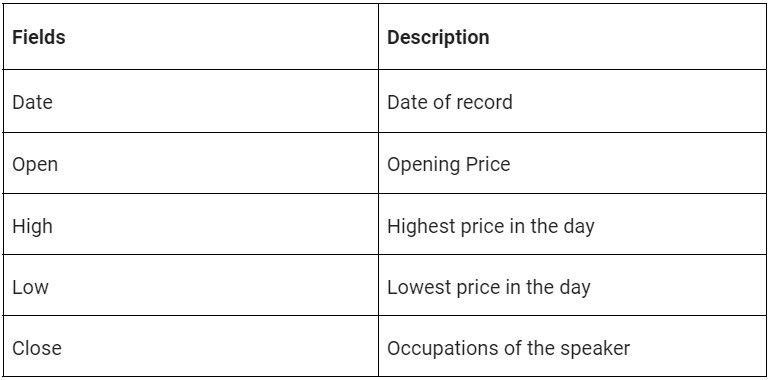

Main Libraries to be Used:

Pandas for data manipulation, aggregation
Matplotlib and Seaborn for visualisation and behaviour with respect to the target variable
NumPy for computationally efficient operations
Scikit Learn for model training, model optimization, and metrics calculation
Deployment (Optional but Great for Placements):

Used Streamlit to build an interactive web app and integrated Gemini API for enhanced language-based interactions, making the project more presentable and impactful during interviews.


Project Architecture:

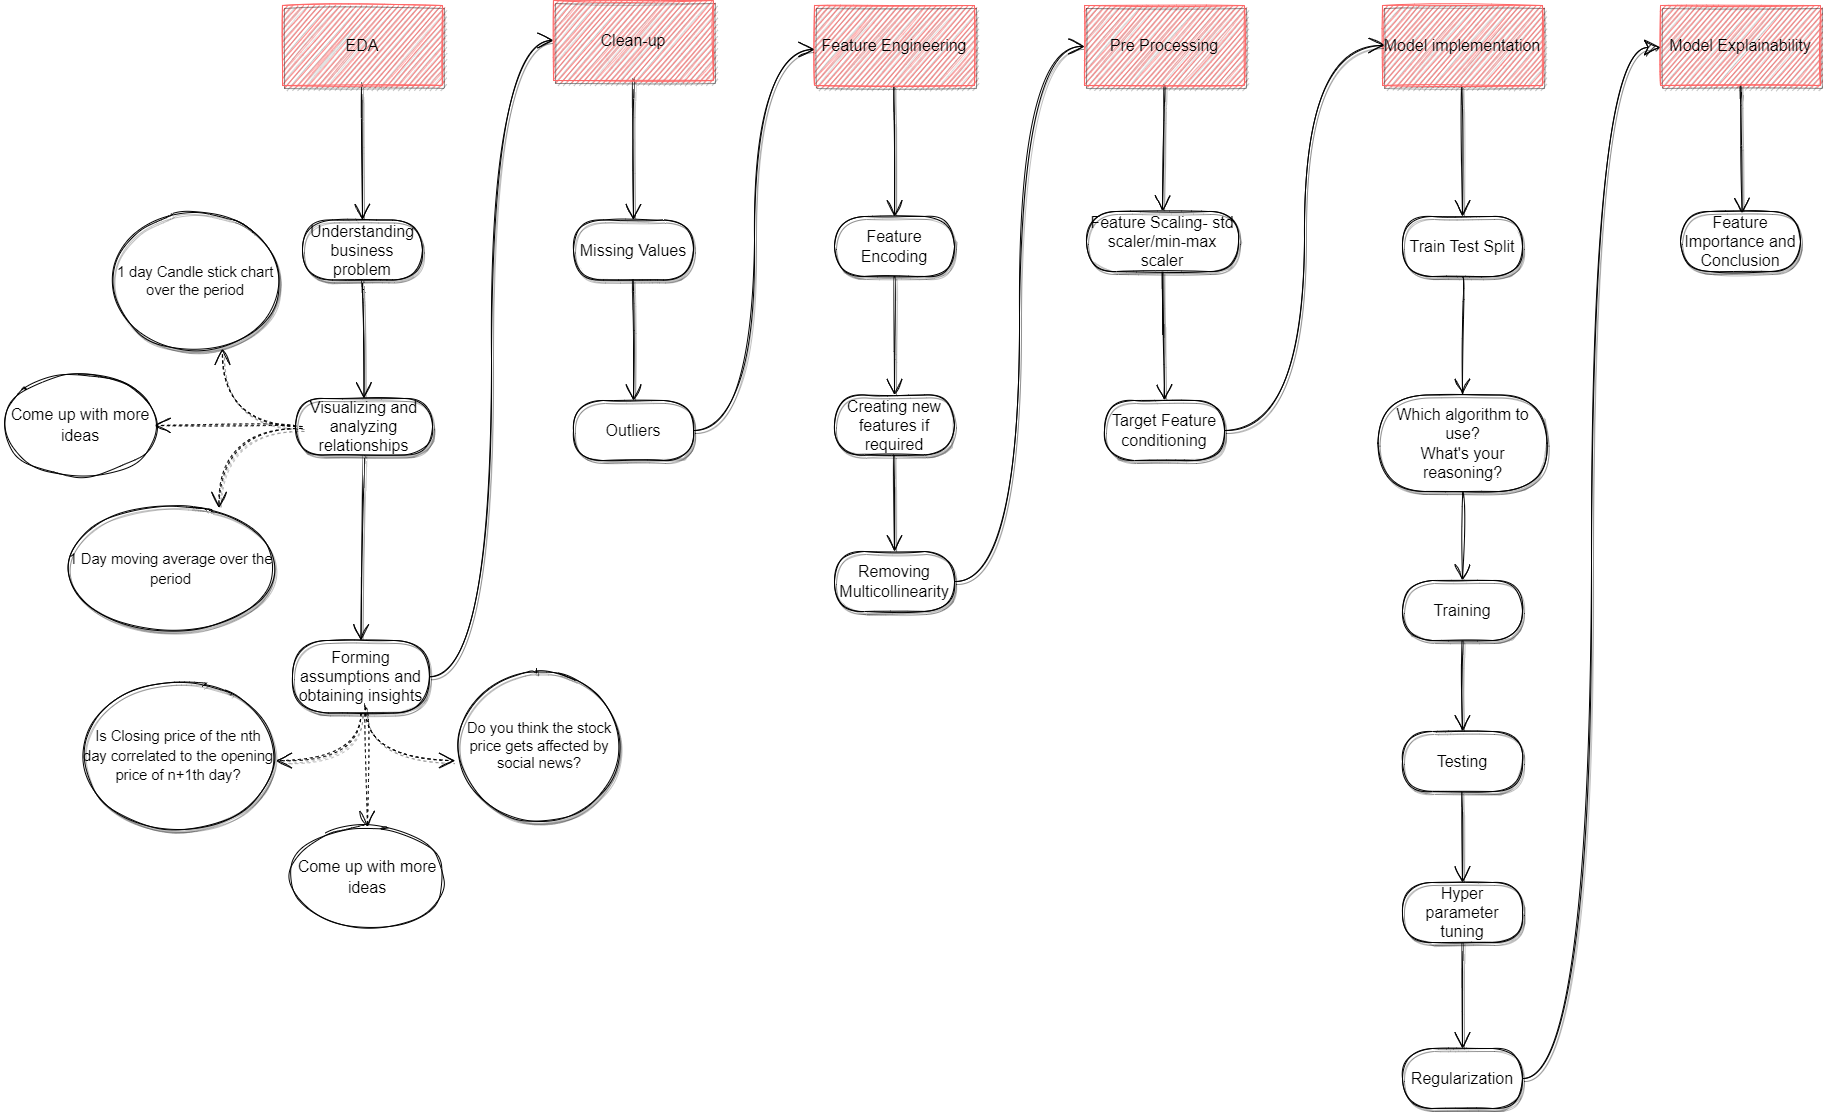

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [ ]:
# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import numpy as np
import datetime as dt
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit, cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, mean_squared_error, r2_score, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
import shap

### Dataset Loading

In [ ]:
# Load Dataset
data = pd.read_csv("https://raw.githubusercontent.com/omkarmohite056-alt/OM-AB-Regression---Yes-Bank-Stock-Closing-Price-Prediction/main/data_YesBank_StockPrices.csv")

### Dataset First View

In [ ]:
# Dataset First Look
data

### Dataset Rows & Columns count

In [ ]:
# Dataset Rows & Columns count
data.shape

### Dataset Information

In [ ]:
# Dataset Info
data.info()

#### Duplicate Values

In [ ]:
# Dataset Duplicate Value Count
data.duplicated().sum()

#### Missing Values/Null Values

In [ ]:
# Missing Values/Null Values Count
data.isnull().sum()

In [ ]:
# Visualizing the missing values
sns.barplot(x=data.columns, y=data.isnull().sum())

### What did you know about your dataset?

There are 185 rows and 5 columns.

There seem to be no duplicates or null values.

## ***2. Understanding Your Variables***

In [ ]:
# Dataset Columns

data.columns

In [ ]:
# Dataset Describe
data.describe()

### Variables Description

Date - The month and year

Open - The opening price of the stock in the month

High - The highest price of the stock in the month

Low - The lowest price of the stock in the month

Close - The closing price of the stock in the month

### Check Unique Values for each variable.

In [ ]:
# Check Unique Values for each variable.
data.nunique()

## 3. ***Data Wrangling***

### Data Wrangling Code

In [ ]:
# Adding a new colomn as datetime object extracted from Date
def to_datetime(x):
  return dt.datetime.strptime(x, '%b-%y')

data['DateTime'] = data['Date'].apply(to_datetime)


data

### What all manipulations have you done and insights you found?

Since the Date column is having date/time related data, extraction has been done to create a more convenient datetime column.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Opening price Univariate plot

In [ ]:
# Chart - 1 visualization code
plt.figure(figsize=(10,5))

sns.histplot(data=data, x='Open', binwidth=10)

plt.show()

##### 1. Why did you pick the specific chart?

Histogram gives us the distribution of the numerical.


##### 2. What is/are the insight(s) found from the chart?

**Right skewed**- The chart is right skewed. There might be outlier months where open price skyrockets.

**Most regular price range**: The open price most frequently falls in the range 10-80. There is also a significant number of times the price falls in 130-210 range.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

The most frequent bin is the 10-20 bin. This must be the price at which the stock was nearly constant for a long period of time.

#### High price Univariate plot

In [ ]:
# Chart - 2 visualization code
plt.figure(figsize=(10,5))

sns.histplot(data=data, x='High', binwidth=10)

plt.show()

##### 1. Why did you pick the specific chart?

Histogram gives us the distribution of the numerical.

##### 2. What is/are the insight(s) found from the chart?

**Right skewed**- The chart is right skewed. There might be outlier months where high price skyrockets.

**Most frequent prices**: The high price of month mostly falls in ranges 10-40 or 50-80.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Same as before

#### Low price Univariate plot

In [ ]:
# Chart - 3 visualization code
plt.figure(figsize=(10,5))

sns.histplot(data=data, x='Low', binwidth=10)

plt.show()

##### 1. Why did you pick the specific chart?

Histogram gives us the distribution of the numerical.

##### 2. What is/are the insight(s) found from the chart?

**Right skewed**- The chart is right skewed. There might be outlier months where low price skyrockets.

**Most frequent prices**: The low price mostly falls in the range 5-65.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Same as before

#### Close price Univariate plot

In [ ]:
# Chart - 4 visualization code
plt.figure(figsize=(10,5))

sns.histplot(data=data, x='Close', binwidth=10)

plt.show()

##### 1. Why did you pick the specific chart?

Histogram gives us the distribution of the numerical.

##### 2. What is/are the insight(s) found from the chart?

**Right skewed**- The chart is right skewed. There might be outlier months where close price skyrockets.

**Most frequent prices**: The price mostly falls in range 10-80.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Same as before

#### Candlestick Chart over Datetime

In [ ]:
# Chart - 9 visualization code
import plotly.graph_objects as go

fig = go.Figure(data=[go.Candlestick(x=data['DateTime'],
                open=data['Open'],
                high=data['High'],
                low=data['Low'],
                close=data['Close'])])

fig.update_layout(title='Candlestick Chart over Datetime',
                  yaxis_title='Stock Prices',
                  xaxis_rangeslider_visible=False)

fig.show()

##### 1. Why did you pick the specific chart?

Candlestick chart is a perfect chart for showing different prices of a stock over period of time.

##### 2. What is/are the insight(s) found from the chart?

**Peak**: The Highest price observed was 404 in the month Aug 2018. The company was doing well since its listing in 2005.

**The Fall**: The first huge fall was right after it reached its peak in Sept 2018 where its closing price was 183.45 from opening price of 347.2.

**The Second Blow**: The stock was doing not too bad following the drop in 2018. Until a year atleast, where in Aug 2018 there was another huge drop from 277 to 168. From that point the stock suffered gradual fall where by the year 2020 it reached its ipo price of 12-14.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

We can clearly see the point of time which caused the stock price drop. The events during the 2018-2019 should be the primary causes.

#### Closing price Average vs Month of the year

In [ ]:
def toMonth(stamp):
  return stamp.strftime('%B')

data['Month'] = data['DateTime'].apply(toMonth)
data['Mno'] = data['DateTime'].apply(lambda x: x.month)

In [ ]:
grouped_data = data[['Close', 'Month', 'Mno']].groupby(['Mno', 'Month']).mean().reset_index().sort_values('Mno')

grouped_data

In [ ]:
# Chart - 10 visualization code
fig = px.bar(grouped_data, x='Month', y='Close', color='Month', title='Closing price Average vs Month of the year')

fig.update_layout(showlegend=False)

fig.show()

##### 1. Why did you pick the specific chart?

Months are categorical, so bar chart is the best for representing this data.

##### 2. What is/are the insight(s) found from the chart?

There is peak in the month April and the lowest is observed in the month September.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This data is the general trend of stock price over months of a year.

####Nth day Close price vs N+1th day Open price

In [ ]:

data.loc[:, 'nextOpen'] = data.loc[1:, 'Open'].reset_index(drop=True)
data['nextOpen'] = data['nextOpen'].fillna(data['Open'])
data


In [ ]:
# Chart - 11 visualization code

fig = px.scatter(data, x='Close', y='nextOpen', title='Nth day Close price vs N+1th day Open price')

fig.show()

##### 1. Why did you pick the specific chart?

We are trying to figure out correlation between two numericals. Scatter is the obvious choice.

##### 2. What is/are the insight(s) found from the chart?

Clearly, there is very strong positive correlation between close and open prices of consecutive days. Correlation is nearly +1.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

The open price clearly starts from where close price left off from the previous day.

## ***5. Hypothesis Testing***

### Based on your chart experiments, define three hypothetical statements from the dataset. In the next three questions, perform hypothesis testing to obtain final conclusion about the statements through your code and statistical testing.

### Hypothetical Statement - 1: Mean Open vs Mean Close price

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Null Hypothesis (H₀):
The mean Open price is equal to the mean Close price.

Alternative Hypothesis (H₁):
The mean Open price is different from the mean Close price.

#### 2. Perform an appropriate statistical test.

In [ ]:
# Perform Statistical Test to obtain P-Value
open_prices = data['Open']
close_prices = data['Close']

t_stat, p_value = stats.ttest_rel(open_prices, close_prices)

print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")

alpha = 0.05
if p_value < alpha:
    print("Reject H0: Mean Open and Close prices are significantly different.")
else:
    print("Fail to Reject H0: No significant difference between mean Open and Close prices.")

##### Which statistical test have you done to obtain P-Value?

Paired t-test

##### Why did you choose the specific statistical test?

Open and Close prices belong to the same month, so observations are dependent (paired).

The test compares the mean of differences between two related samples.

### Hypothetical Statement - 2: Seasonality effect (April vs September Close prices)

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Null Hypothesis (H₀):
The mean Close price in April is equal to the mean Close price in September.

Alternative Hypothesis (H₁):
The mean Close price in April is higher than that in September.

#### 2. Perform an appropriate statistical test.

In [ ]:
# Perform Statistical Test to obtain P-Value

april_close = data[data['Mno'] == 4]['Close']
september_close = data[data['Mno'] == 9]['Close']

# Two-sample t-test (Welch’s t-test)
t_stat, p_two_tailed = stats.ttest_ind(
    april_close,
    september_close,
    equal_var=False
)

# Convert to one-tailed p-value (April > September)
p_one_tailed = p_two_tailed / 2

print(f"T-statistic: {t_stat:.4f}")
print(f"One-tailed P-value: {p_one_tailed:.4f}")

alpha = 0.05
if p_one_tailed < alpha:
    print("Reject H0: April mean Close price is significantly higher than September.")
else:
    print("Fail to Reject H0: No significant seasonal difference between April and September.")

##### Which statistical test have you done to obtain P-Value?

Two-sample t-test (Welch’s t-test)

##### Why did you choose the specific statistical test?

April and September Close prices are from two independent groups.

Sample sizes may differ and variances may not be equal.

Welch’s t-test does not assume equal variance, making it more robust.

### Hypothetical Statement - 3: Correlation between Close (t) and Open (t+1)

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Null Hypothesis (H₀):
There is no correlation between Close price on day t and Open price on day t+1.

Alternative Hypothesis (H₁):
There is a significant positive correlation between Close price on day t and Open price on day t+1.

#### 2. Perform an appropriate statistical test.

In [ ]:
# Perform Statistical Test to obtain P-Value

close_t = data['Close']
open_t1 = data['nextOpen']

# Pearson correlation test
corr, p_two_tailed = stats.pearsonr(close_t, open_t1)

# Convert to one-tailed p-value (positive correlation)
p_one_tailed = p_two_tailed / 2

print(f"Pearson Correlation: {corr:.4f}")
print(f"One-tailed P-value: {p_one_tailed:.6f}")

alpha = 0.05
if p_one_tailed < alpha:
    print("Reject H0: Significant positive correlation exists between Close(t) and Open(t+1).")
else:
    print("Fail to Reject H0: No significant positive correlation detected.")

##### Which statistical test have you done to obtain P-Value?

Pearson correlation significance test

##### Why did you choose the specific statistical test?

Both variables are continuous.

Relationship observed appeared linear.

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [ ]:
# Handling Missing Values & Missing Value Imputation

#### What all missing value imputation techniques have you used and why did you use those techniques?

The dataset contains no null values in any of the columns. So nothing is required.

### 2. Handling Outliers

In [ ]:
# Handling Outliers & Outlier treatments

##### What all outlier treatment techniques have you used and why did you use those techniques?

Although the dataset exhibits extreme values, these outliers correspond to genuine market events, particularly the rapid rise and subsequent crash in Yes Bank’s stock price following the 2018 fraud case. Since the objective of the study is to analyze the impact of such events and evaluate the effectiveness of predictive models under real market conditions, no outlier removal was performed. Preserving these values ensures that the models capture structural breaks and volatility inherent in financial time series.

### 3. Categorical Encoding

In [ ]:
# Encode your categorical columns

#### What all categorical encoding techniques have you used & why did you use those techniques?

Date column has already been converted to DateTime of type datetime.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [ ]:
# Manipulate Features to minimize feature correlation and create new features
data['Log_Close'] = np.log(data['Close'])

data['Log_Close_lag1'] = data['Log_Close'].shift(1)
data['Log_Close_lag2'] = data['Log_Close'].shift(2)
data['Log_Close_lag3'] = data['Log_Close'].shift(3)

data['HL_Range'] = data['High'] - data['Low']
data['OC_Range'] = data['Open'] - data['Close']

data['MA_3'] = data['Log_Close'].rolling(3).mean()
data['MA_6'] = data['Log_Close'].rolling(6).mean()

data_fs = data.dropna().copy()

data_fs = data_fs.sort_values('DateTime')

data_fs = data_fs.set_index('DateTime')

#### 2. Feature Selection

In [ ]:
# Select your features wisely to avoid overfitting
y = data_fs['Log_Close']
X = data_fs[['Log_Close_lag1', 'HL_Range', 'OC_Range', 'MA_3']]

##### What all feature selection methods have you used  and why?

Removed redundant engineered features-
Based on:

* Very high autocorrelation

* Rolling windows overlapping information

##### Which all features you found important and why?

1. Log_Close_lag1 (Previous Month Closing Price) - Hypothesis testing showed an extremely strong positive correlation (≈ 0.9999) between consecutive prices.
2. HL_Range (High–Low Price Range) - Measures monthly volatility.
3. OC_Range (Open–Close Price Difference) - Positive or negative movement between open and close reflects market sentiment.
4. MA_3 (3-Month Moving Average of Log Close) - Smooths short-term noise while remaining responsive to regime changes.

### 5. Data Transformation

#### Do you think that your data needs to be transformed? If yes, which transformation have you used. Explain Why?

In [ ]:
# Transform Your data

### 6. Data Scaling

In [ ]:
# Scaling your data

##### Which method have you used to scale you data and why?

No further transformation/scaling is required.

### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

No Dimensional Reduction is needed.

In [ ]:
# DImensionality Reduction (If needed)

##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

No dimensionality reduction is required.

### 8. Data Splitting

In [ ]:
# Split your data to train and test. Choose Splitting ratio wisely.
split_date = '2018-01-01'

# Chronological split
X_train = X.loc[X.index < split_date]
X_test  = X.loc[X.index >= split_date]

y_train = y.loc[y.index < split_date]
y_test  = y.loc[y.index >= split_date]

# Sanity check
print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

assert X_train.index.equals(y_train.index)
assert X_test.index.equals(y_test.index)

##### What data splitting ratio have you used and why?

The dataset was split chronologically to preserve temporal order and avoid information leakage. Observations prior to 2018 were used for training, while data from 2018 onwards was reserved for testing to evaluate model performance during the period affected by the fraud event.

### 9. Handling Imbalanced Dataset

##### Do you think the dataset is imbalanced? Explain Why.

The dataset is balanced.

In [ ]:
# Handling Imbalanced Dataset (If needed)

##### What technique did you use to handle the imbalance dataset and why? (If needed to be balanced)

None.

## ***7. ML Model Implementation***

### ML Model - 1 Baseline (Naive Lag Model)

In [ ]:
# ML Model - 1 Implementation

# Fit the Algorithm
# (No fitting required — naive baseline)

# Predict on the model
y_pred_baseline = X_test['Log_Close_lag1']

In [ ]:
def evaluate_model(y_true_log, y_pred_log, model_name):
    y_true = np.exp(y_true_log)
    y_pred = np.exp(y_pred_log)

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)

    return pd.DataFrame({
        'Model': [model_name],
        'RMSE': [rmse],
        'MAE': [mae]
    })

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [ ]:
# Visualizing evaluation Metric Score chart
# Predict
y_pred_baseline = X_test['Log_Close_lag1']

# Evaluate
baseline_results = evaluate_model(
    y_test,
    y_pred_baseline,
    "Baseline (Lag-1)"
)

baseline_results

#### 2. Cross- Validation & Hyperparameter Tuning

The baseline model does not involve trainable parameters; therefore, cross-validation and hyperparameter tuning are not applicable.

### ML Model - 2 Linear Regression

In [ ]:
# Fit the Algorithm
lr = LinearRegression()
lr.fit(X_train, y_train)

# Predict on the model
y_pred_lr = lr.predict(X_test)

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [ ]:
# Visualizing evaluation Metric Score chart
# Fit
lr = LinearRegression()
lr.fit(X_train, y_train)

# Predict
y_pred_lr = lr.predict(X_test)

# Evaluate
lr_results = evaluate_model(
    y_test,
    y_pred_lr,
    "Linear Regression"
)

lr_results

#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

tscv = TimeSeriesSplit(n_splits=5)

cv_rmse = -cross_val_score(
    lr,
    X_train,
    y_train,
    cv=tscv,
    scoring='neg_root_mean_squared_error'
)

print("CV RMSE scores:", cv_rmse)
print("Mean CV RMSE:", cv_rmse.mean())

##### Which hyperparameter optimization technique have you used and why?

TimeSeries Cross-Validation (TimeSeriesSplit)

Linear Regression has no major tunable hyperparameters.

Cross-validation was used to:

* Validate model stability

* Ensure performance consistency across time

TimeSeriesSplit preserves temporal order, preventing data leakage.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Cross-validation results

* Mean CV RMSE (log-scale): 0.1416

* Indicates stable generalization

Significant improvement over baseline.

Model benefits from volatility and trend features.

### ML Model - 3 Random Forest Regressor

In [ ]:
# ML Model - 3 Implementation

# Fit the Algorithm
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)
rf.fit(X_train, y_train)

# Predict on the model
y_pred_rf = rf.predict(X_test)

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [ ]:
# Visualizing evaluation Metric Score chart
# Fit
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)
rf.fit(X_train, y_train)

# Predict
y_pred_rf = rf.predict(X_test)

# Evaluate
rf_results = evaluate_model(
    y_test,
    y_pred_rf,
    "Random Forest"
)

rf_results

#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
# ML Model - 3 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5]
}

tscv = TimeSeriesSplit(n_splits=5)

grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

grid.fit(X_train, y_train)

best_rf = grid.best_estimator_

# Predict with tuned model
y_pred_rf_tuned = best_rf.predict(X_test)

# Evaluate
rf_tuned_results = evaluate_model(
    y_test,
    y_pred_rf_tuned,
    "Random Forest (Tuned)"
)

rf_tuned_results

##### Which hyperparameter optimization technique have you used and why?

Grid Search with TimeSeriesSplit

Random Forest has multiple tunable hyperparameters.

Grid Search systematically evaluates combinations.

TimeSeriesSplit ensures: Temporal integrity, No future data leakage

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Increasing model complexity did not lead to better generalization.

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

RMSE and MAE were selected as evaluation metrics as they directly quantify prediction error in price terms. RMSE captures risk from large deviations, while MAE provides an interpretable average error, both of which are critical for financial decision-making.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

Linear Regression was selected as the final prediction model due to its superior RMSE performance, stability, and interpretability, making it more suitable for business decision-making in a financial context.

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

In [ ]:
# Train final model (already done, shown for clarity)
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train, y_train)

# SHAP explainer
explainer = shap.Explainer(lr, X_train)
shap_values = explainer(X_train)

# Summary plot
shap.summary_plot(shap_values, X_train)

Model explainability analysis using SHAP revealed that the previous month’s closing price had the strongest influence on predictions, followed by short-term trend indicators and volatility measures. This aligns with financial theory and reinforces confidence in the model’s predictions.

# **Conclusion**

This project analyzed monthly stock prices of Yes Bank from 2005 to 2020 to study the impact of major market events and to forecast monthly closing prices. Exploratory analysis identified strong temporal dependence and significant volatility around the 2018 fraud period. Feature engineering focused on lagged prices, volatility measures, and short-term trends, while retaining all genuine market outliers. Log transformation of the closing price was applied to stabilize variance without removing critical market information.

Three models were evaluated: a naive baseline, Linear Regression, and Random Forest. Linear Regression emerged as the final model due to its superior RMSE performance, stability, and interpretability. Explainability analysis confirmed that the previous month’s closing price was the most influential predictor, supported by trend and volatility features. The study demonstrates that well-engineered simple models can effectively capture stock price behavior and provide reliable predictions in volatile financial environments.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***